##### Copyright 2026 Google LLC.

Graph Data: {'1': ['2', '3'], '2': ['1', '4', '5'], '3': ['1', '6'], '4': ['2'], '5': ['2', '6'], '6': ['3', '5']}

DFS Result: ['1', '2', '4', '5', '6', '3']

BFS Result: ['1', '2', '3', '4', '5', '6']

Shortest Path 1 → 6: 1 -> 3 -> 6


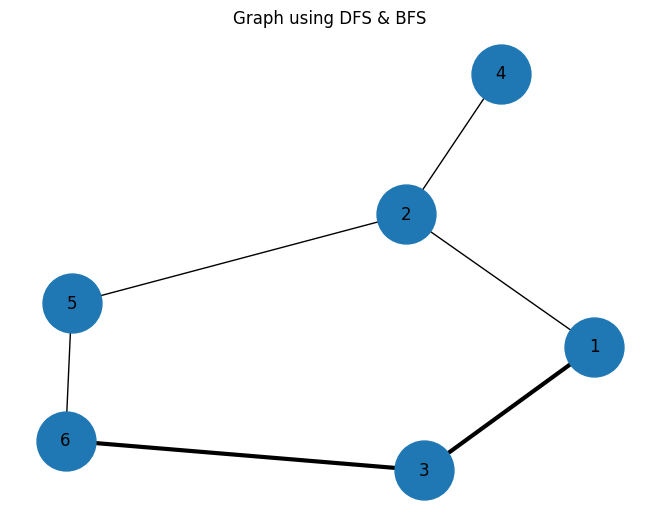

In [4]:
# ============================================================
# AI Assignment: DFS and BFS (Modified Version)
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# Graph (changed labels)
graph_data = {
    '1': ['2', '3'],
    '2': ['1', '4', '5'],
    '3': ['1', '6'],
    '4': ['2'],
    '5': ['2', '6'],
    '6': ['3', '5']
}

# ---------------- DFS ----------------
def depth_first_search(g, start_node, visited_nodes=None, result=None):
    if visited_nodes is None:
        visited_nodes = set()
    if result is None:
        result = []

    visited_nodes.add(start_node)
    result.append(start_node)

    for next_node in g[start_node]:
        if next_node not in visited_nodes:
            depth_first_search(g, next_node, visited_nodes, result)

    return result

# ---------------- BFS ----------------
def breadth_first_search(g, start_node):
    visited_nodes = set([start_node])
    q = deque([start_node])
    result = []

    while q:
        current = q.popleft()
        result.append(current)

        for next_node in g[current]:
            if next_node not in visited_nodes:
                visited_nodes.add(next_node)
                q.append(next_node)

    return result

# -------- SHORTEST PATH USING BFS ----------
def shortest_path_bfs(g, start, end):
    visited_nodes = set([start])
    q = deque([[start]])

    while q:
        path = q.popleft()
        last_node = path[-1]

        if last_node == end:
            return path

        for next_node in g[last_node]:
            if next_node not in visited_nodes:
                visited_nodes.add(next_node)
                q.append(path + [next_node])

    return None

# -------- GRAPH DRAWING --------
def show_graph(g, path=None):
    G = nx.Graph()

    for node in g:
        for neighbour in g[node]:
            G.add_edge(node, neighbour)

    pos = nx.spring_layout(G)

    nx.draw(G, pos, with_labels=True, node_size=1800)

    if path:
        edge_list = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, width=3)

    plt.title("Graph using DFS & BFS")
    plt.show()

# ---------------- MAIN ----------------
if __name__ == "__main__":
    print("Graph Data:", graph_data)

    dfs_result = depth_first_search(graph_data, '1')
    print("\nDFS Result:", dfs_result)

    bfs_result = breadth_first_search(graph_data, '1')
    print("\nBFS Result:", bfs_result)

    shortest = shortest_path_bfs(graph_data, '1', '6')
    print("\nShortest Path 1 → 6:", " -> ".join(shortest))

    show_graph(graph_data, shortest)